<a href="https://colab.research.google.com/github/sudhans18/ABDA/blob/main/01_CMU_MOSEI_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install -q -U sentence-transformers scikit-learn pandas matplotlib seaborn

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

In [10]:
from sentence_transformers import SentenceTransformer
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model = SentenceTransformer(
    "sentence-transformers/LaBSE",
    device=device
)

print("Model loaded.")
print("Device:", device)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


modules.json:   0%|          | 0.00/461 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/2.02k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors: reconstructing file:   0%|          |  0.00B / 2.36MB            

2_Dense/model.safetensors: downloading bytes:           |  0.00B            

Model loaded.
Device: cpu


In [11]:
sentences = [
    "I am very happy today.",
    "I am feeling really good today.",
    "Today has been a wonderful day.",
    "I am working on my electronics project.",
    "The circuit board needs to be repaired.",
    "I went to the supermarket yesterday.",
    "The weather is sunny today.",
    "I enjoy spending time with my friends."
]

embeddings = model.encode(
    sentences,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Embedding shape:", embeddings.shape)

Embedding shape: (8, 768)


In [12]:
similarity_matrix = cosine_similarity(embeddings)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=sentences,
    columns=sentences
)

similarity_df.round(3)

,I am very happy today.,I am feeling really good today.,Today has been a wonderful day.,I am working on my electronics project.,The circuit board needs to be repaired.,I went to the supermarket yesterday.,The weather is sunny today.,I enjoy spending time with my friends.
I am very happy today.,1.000,0.841,0.693,0.293,0.186,0.392,0.629,0.425
I am feeling really good today.,0.841,1.000,0.657,0.297,0.204,0.365,0.634,0.450
Today has been a wonderful day.,0.693,0.657,1.000,0.165,0.175,0.347,0.688,0.288
I am working on my electronics project.,0.293,0.297,0.165,1.000,0.214,0.254,0.214,0.328
The circuit board needs to be repaired.,0.186,0.204,0.175,0.214,1.000,0.119,0.195,0.127
I went to the supermarket yesterday.,0.392,0.365,0.347,0.254,0.119,1.000,0.224,0.218
The weather is sunny today.,0.629,0.634,0.688,0.214,0.195,0.224,1.000,0.321
I enjoy spending time with my friends.,0.425,0.450,0.288,0.328,0.127,0.218,0.321,1.000


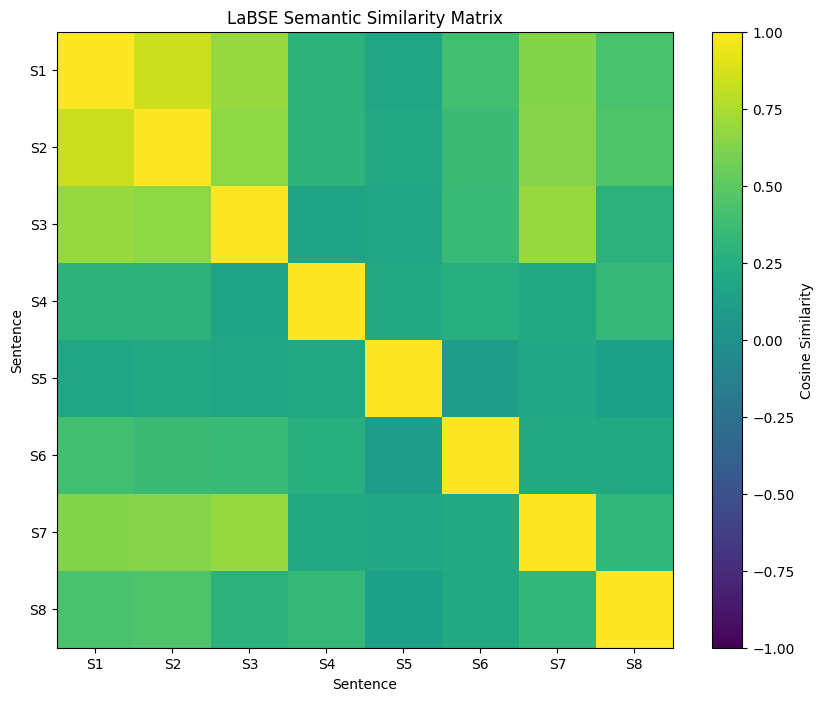

In [13]:
plt.figure(figsize=(10, 8))

plt.imshow(
    similarity_matrix,
    cmap="viridis",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Cosine Similarity")

plt.xticks(
    range(len(sentences)),
    [f"S{i+1}" for i in range(len(sentences))]
)

plt.yticks(
    range(len(sentences)),
    [f"S{i+1}" for i in range(len(sentences))]
)

plt.title("LaBSE Semantic Similarity Matrix")
plt.xlabel("Sentence")
plt.ylabel("Sentence")

plt.show()

In [14]:
pairs = []

for i in range(len(sentences)):
    for j in range(i + 1, len(sentences)):
        pairs.append({
            "sentence_1": sentences[i],
            "sentence_2": sentences[j],
            "similarity": similarity_matrix[i, j]
        })

pairs_df = pd.DataFrame(pairs)

pairs_df = pairs_df.sort_values(
    by="similarity",
    ascending=False
)

In [15]:
pairs_df["semantic_distance"] = 1 - pairs_df["similarity"]

pairs_df.head(10)

,sentence_1,sentence_2,similarity,semantic_distance
0,I am very happy today.,I am feeling really good today.,0.841319,0.158681
1,I am very happy today.,Today has been a wonderful day.,0.693222,0.306778
16,Today has been a wonderful day.,The weather is sunny today.,0.687974,0.312026
7,I am feeling really good today.,Today has been a wonderful day.,0.656751,0.343249
11,I am feeling really good today.,The weather is sunny today.,0.634201,0.365799
5,I am very happy today.,The weather is sunny today.,0.629102,0.370898
12,I am feeling really good today.,I enjoy spending time with my friends.,0.449740,0.550260
6,I am very happy today.,I enjoy spending time with my friends.,0.425434,0.574566
4,I am very happy today.,I went to the supermarket yesterday.,0.392406,0.607594
10,I am feeling really good today.,I went to the supermarket yesterday.,0.365026,0.634974


In [16]:
pca = PCA(n_components=2)

embeddings_2d = pca.fit_transform(embeddings)

print("Original shape:", embeddings.shape)
print("Reduced shape:", embeddings_2d.shape)

Original shape: (8, 768)
Reduced shape: (8, 2)


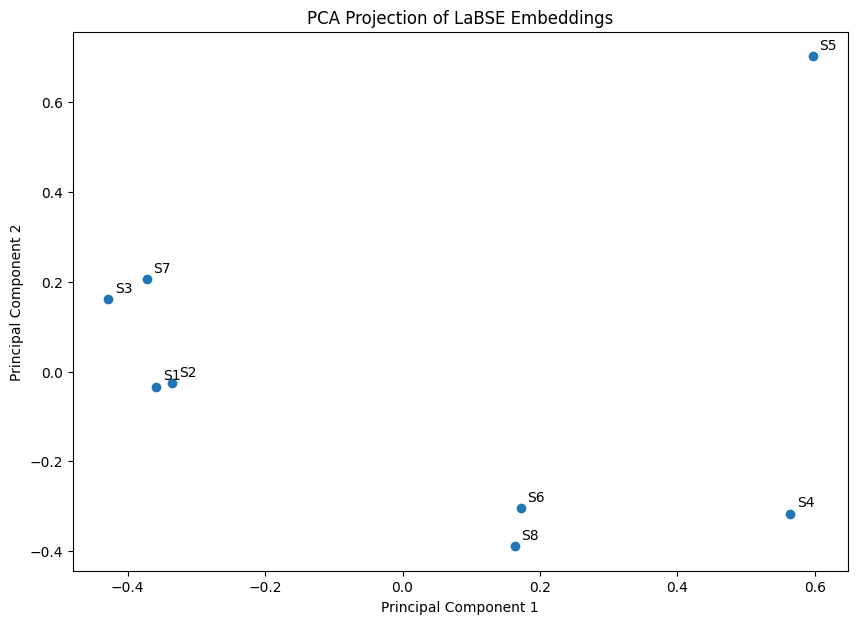

In [17]:
plt.figure(figsize=(10, 7))

plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1]
)

for i, sentence in enumerate(sentences):
    plt.annotate(
        f"S{i+1}",
        (embeddings_2d[i, 0], embeddings_2d[i, 1]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of LaBSE Embeddings")

plt.show()

# CMU MOSEI LOADING AND PREPROCESSING

In [18]:
!git clone https://github.com/CMU-MultiComp-Lab/CMU-MultimodalSDK.git
%cd CMU-MultimodalSDK
!pip install -q .
%cd ..

Cloning into 'CMU-MultimodalSDK'...
remote: Enumerating objects: 100, done.
remote: Counting objects: 100% (100/100), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 100 (delta 13), reused 95 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (100/100), 294.06 KiB | 1.24 MiB/s, done.
Resolving deltas: 100% (13/13), done.
/content/CMU-MultimodalSDK
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 3.0 MB/s eta 0:00:00
/content


In [19]:
from mmsdk import mmdatasdk

words_dataset = mmdatasdk.mmdataset(
    {
        "words": "/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_TimestampedWords.csd"
    }
)

[2026-09-09 13:39:51.556] | Success | Computational sequence read from file /content/drive/MyDrive/cmu_mosei/CMU_MOSEI_TimestampedWords.csd ...
[2026-09-09 13:40:04.956] | Status  | Checking the integrity of the <words> computational sequence ...
[2026-09-09 13:40:04.965] | Status  | Checking the format of the data in <words> computational sequence ...


[2026-09-09 13:40:28.667] | Success | <words> computational sequence data in correct format.
[2026-09-09 13:40:28.667] | Status  | Checking the format of the metadata in <words> computational sequence ...
[2026-09-09 13:40:28.667] | Warning | <words> computational sequence does not have all the required metadata ... continuing 
[2026-09-09 13:40:28.667] | Success | Dataset initialized successfully ... 


In [20]:
words = words_dataset["words"]
print(words)
print(words.__dict__.keys())

dict_keys(['main_file', 'data', 'metadata', 'root_name', 'h5handle', 'rootName'])


In [21]:
def inspect_structure(obj, name="root", depth=0, max_depth=3):
    indent = "  " * depth

    print(f"{indent}{name}: {type(obj)}")

    if depth >= max_depth:
        return

    if isinstance(obj, dict):
        keys = list(obj.keys())

        print(f"{indent}  Number of keys: {len(keys)}")

        for key in keys[:3]:
            inspect_structure(
                obj[key],
                f"[{key}]",
                depth + 1,
                max_depth
            )

    elif hasattr(obj, "shape"):
        print(f"{indent}  Shape: {obj.shape}")

    elif hasattr(obj, "dtype"):
        print(f"{indent}  Dtype: {obj.dtype}")

In [22]:
inspect_structure(words.data)

root: <class 'dict'>
  Number of keys: 3837
  [--qXJuDtHPw]: <class 'h5py._hl.group.Group'>
  [-3g5yACwYnA]: <class 'h5py._hl.group.Group'>
  [-3nNcZdcdvU]: <class 'h5py._hl.group.Group'>


In [23]:
print("Number of segments:", len(words.data))
print("First 10 IDs:")
print(list(words.data.keys())[:10])

Number of segments: 3837
First 10 IDs:
['--qXJuDtHPw', '-3g5yACwYnA', '-3nNcZdcdvU', '-571d8cVauQ', '-6rXp3zJ3kc', '-9YyBTjo1zo', '-9y-fZ3swSY', '-AUZQgSxyPQ', '-Alixo7euuU', '-Eqdz5y4pEY']


In [24]:
first_key = list(words.data.keys())[0]

print("ID:", first_key)
print("Entry type:", type(words.data[first_key]))

ID: --qXJuDtHPw
Entry type: <class 'h5py._hl.group.Group'>


In [25]:
inspect_structure(words.data, max_depth=4)

root: <class 'dict'>
  Number of keys: 3837
  [--qXJuDtHPw]: <class 'h5py._hl.group.Group'>
  [-3g5yACwYnA]: <class 'h5py._hl.group.Group'>
  [-3nNcZdcdvU]: <class 'h5py._hl.group.Group'>


In [26]:
first_key = list(words.data.keys())[0]
group = words.data[first_key]

print("Segment ID:", first_key)
print("Group keys:", list(group.keys()))

Segment ID: --qXJuDtHPw
Group keys: ['features', 'intervals']


In [27]:
first_key = list(words.data.keys())[0]
group = words.data[first_key]

features = group["features"][:20]
intervals = group["intervals"][:20]

for interval, feature in zip(intervals, features):
    word = feature[0].decode("utf-8")

    print(
        f"{interval[0]:.3f} - {interval[1]:.3f} : {word}"
    )

0.012 - 0.072 : sp
0.072 - 0.262 : i
0.262 - 0.471 : see
0.471 - 0.591 : that
0.591 - 0.781 : there
0.781 - 0.811 : are
0.811 - 1.070 : three
1.070 - 1.579 : category
1.579 - 1.649 : sp
1.649 - 1.768 : of
1.768 - 2.407 : writers
2.407 - 2.696 : sp
2.696 - 2.906 : i
2.906 - 3.325 : define
3.325 - 3.475 : them
3.475 - 3.684 : as
3.684 - 4.702 : being
4.702 - 5.051 : an
5.051 - 5.181 : sp
5.181 - 5.600 : author


In [28]:
all_transcripts = []

for segment_id, group in words.data.items():

    features = group["features"][:]
    intervals = group["intervals"][:]

    words_list = []

    for feature in features:
        word = feature[0].decode("utf-8")
        words_list.append(word)

    transcript = " ".join(words_list)

    all_transcripts.append({
        "segment_id": segment_id,
        "transcript": transcript
    })

transcripts_df = pd.DataFrame(all_transcripts)

print("Number of transcripts:", len(transcripts_df))

transcripts_df.head()

Number of transcripts: 3837


,segment_id,transcript
0,--qXJuDtHPw,sp i see that there are three category sp of w...
1,-3g5yACwYnA,hi my name is raj shah i'm from coating i'm vi...
2,-3nNcZdcdvU,introduction sp speaker dr erma jean sims sono...
3,-571d8cVauQ,sp this is rhett reiger white caspian studios ...
4,-6rXp3zJ3kc,sp this is financial adviser patrick munro ans...


In [29]:
empty_mask = (
    transcripts_df["transcript"]
    .str.strip()
    .eq("")
)

print("Empty transcripts:", empty_mask.sum())

Empty transcripts: 0


In [30]:
transcripts_df["word_count"] = (
    transcripts_df["transcript"]
    .str.split()
    .str.len()
)

transcripts_df["char_count"] = (
    transcripts_df["transcript"]
    .str.len()
)

transcripts_df[[
    "word_count",
    "char_count"
]].describe()

,word_count,char_count
count,3837.000000,3837.000000
mean,282.513683,1390.004952
std,152.128517,747.621107
min,17.000000,88.000000
25%,183.000000,913.000000
50%,244.000000,1184.000000
75%,347.000000,1689.000000
max,1194.000000,6321.000000


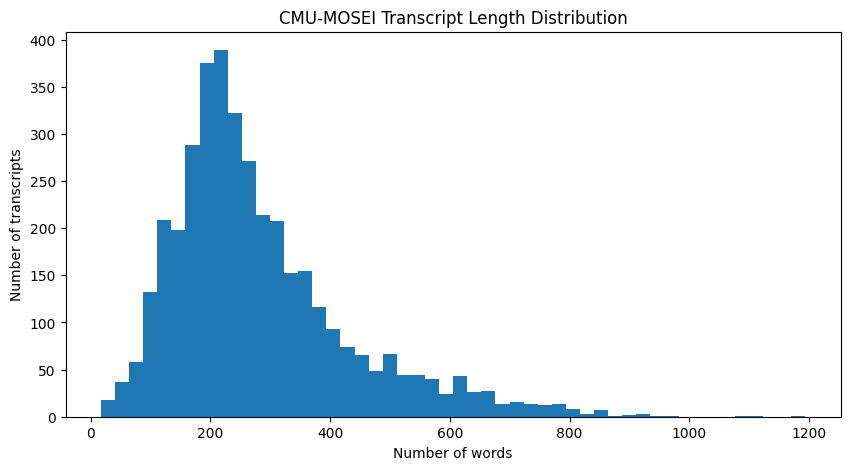

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    transcripts_df["word_count"],
    bins=50
)

plt.xlabel("Number of words")
plt.ylabel("Number of transcripts")
plt.title("CMU-MOSEI Transcript Length Distribution")

plt.show()

In [32]:
transcripts_df.to_csv(
    "/content/drive/MyDrive/cmu_mosei/"
    "CMU_MOSEI_transcripts.csv",
    index=False
)

In [33]:
import re

def clean_transcript(text):
    # Remove the CMU-MOSEI "sp" annotation
    text = re.sub(r'\bsp\b', ' ', text)

    # Normalize repeated whitespace
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

transcripts_df["clean_transcript"] = (
    transcripts_df["transcript"]
    .apply(clean_transcript)
)

transcripts_df[
    ["transcript", "clean_transcript"]
].head(10)

,transcript,clean_transcript
0,sp i see that there are three category sp of w...,i see that there are three category of writers...
1,hi my name is raj shah i'm from coating i'm vi...,hi my name is raj shah i'm from coating i'm vi...
2,introduction sp speaker dr erma jean sims sono...,introduction speaker dr erma jean sims sonoma ...
3,sp this is rhett reiger white caspian studios ...,this is rhett reiger white caspian studios on ...
4,sp this is financial adviser patrick munro ans...,this is financial adviser patrick munro answer...
5,sp with approval ratings in the low sp if you'...,with approval ratings in the low if you're gon...
6,is you can say hey sp i really like sp baby sk...,is you can say hey i really like baby skin the...
7,sp this sp is the sp refining sp skin polish s...,this is the refining skin polish call your own...
8,hey what's going on i wanted to do a video abo...,hey what's going on i wanted to do a video abo...
9,sp i think sp crucial sp we come out sp of sp ...,i think crucial we come out of a brand years o...


In [34]:
print("Model maximum sequence length:",
      model.max_seq_length)

token_lengths = []

sample_texts = transcripts_df["clean_transcript"].head(1000).tolist()

for text in sample_texts:
    tokens = model.tokenizer(
        text,
        truncation=False,
        add_special_tokens=True
    )

    token_lengths.append(
        len(tokens["input_ids"])
    )

print("Mean:", np.mean(token_lengths))
print("Median:", np.median(token_lengths))
print("95th percentile:", np.percentile(token_lengths, 95))
print("Maximum:", np.max(token_lengths))

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (395 > 256). Running this sequence through the model will result in indexing errors


Model maximum sequence length: 256
Mean: 298.855
Median: 272.0
95th percentile: 555.1499999999999
Maximum: 1187


In [35]:
!wget -O "/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_Labels.csd" \
"https://huggingface.co/datasets/reeha-parkar/cmu-mosei-comp-seq/resolve/main/data/CMU_MOSEI_Labels.csd"

--2026-09-09 13:42:39--  https://huggingface.co/datasets/reeha-parkar/cmu-mosei-comp-seq/resolve/main/data/CMU_MOSEI_Labels.csd
Resolving huggingface.co (huggingface.co)... 18.238.109.92, 18.238.109.102, 18.238.109.52, ...
Connecting to huggingface.co (huggingface.co)|18.238.109.92|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/68614f478079ed0483256b02/18aba948d399b6299cfbf956628d71da99cb0c3ff011a203b64e6a58a9b3b523?X-Xet-Cas-Uid=public&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27CMU_MOSEI_Labels.csd%3B+filename%3D%22CMU_MOSEI_Labels.csd%22%3B&user_id=public&Expires=1788964959&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjg2MTRmNDc4MDc5ZWQwNDgzMjU2YjAyLzE4YWJhOTQ4ZDM5OWI2Mjk5Y2ZiZjk1NjYyOGQ3MWRhOTljYjBjM2ZmMDExYTIwM2I2NGU2YTU4YTliM2I1MjNcXD9YLVhldC1DYXMtVWlkPXB1YmxpYyZyZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPSomdXNlcl9pZD1wdWJsaWMiLCJDb25kaXRpb24iOnsi

In [36]:
labels_dataset = mmdatasdk.mmdataset(
    {
        "labels": "/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_Labels.csd"
    }
)

labels = labels_dataset["labels"]

print(type(labels))
print(len(labels.data))

first_label_id = list(labels.data.keys())[0]

print("First ID:", first_label_id)
print("Keys:", list(labels.data[first_label_id].keys()))

[2026-09-09 13:44:14.466] | Success | Computational sequence read from file /content/drive/MyDrive/cmu_mosei/CMU_MOSEI_Labels.csd ...
[2026-09-09 13:44:15.240] | Status  | Checking the integrity of the <All Labels> computational sequence ...
[2026-09-09 13:44:15.240] | Status  | Checking the format of the data in <All Labels> computational sequence ...


[2026-09-09 13:44:17.412] | Success | <All Labels> computational sequence data in correct format.
[2026-09-09 13:44:17.412] | Status  | Checking the format of the metadata in <All Labels> computational sequence ...
[2026-09-09 13:44:17.412] | Warning | <All Labels> computational sequence does not have all the required metadata ... continuing 
[2026-09-09 13:44:17.412] | Success | Dataset initialized successfully ... 
<class 'mmsdk.mmdatasdk.computational_sequence.computational_sequence.computational_sequence'>
3293
First ID: --qXJuDtHPw
Keys: ['features', 'intervals']


In [37]:
for key in labels.data[first_label_id].keys():
    item = labels.data[first_label_id][key]

    print("\nKEY:", key)
    print("TYPE:", type(item))

    if hasattr(item, "shape"):
        print("SHAPE:", item.shape)

    if hasattr(item, "dtype"):
        print("DTYPE:", item.dtype)


KEY: features
TYPE: <class 'h5py._hl.dataset.Dataset'>
SHAPE: (1, 7)
DTYPE: float32

KEY: intervals
TYPE: <class 'h5py._hl.dataset.Dataset'>
SHAPE: (1, 2)
DTYPE: float64


In [38]:
def get_words_for_interval(segment_id, start, end):
    group = words.data[segment_id]

    intervals = group["intervals"][:]
    features = group["features"][:]

    selected_words = []

    for interval, feature in zip(intervals, features):

        word_start = float(interval[0])
        word_end = float(interval[1])

        if word_end > start and word_start < end:

            word = feature[0].decode("utf-8").strip()

            # Remove CMU-MOSEI speech/pause annotation
            if word.lower() == "sp":
                continue

            selected_words.append(
                (word_start, word_end, word)
            )

    # CSD entries are not necessarily chronologically ordered
    selected_words.sort(key=lambda x: x[0])

    return selected_words

In [39]:
segment_id = "--qXJuDtHPw"

label_start = 23.199
label_end = 30.325

selected_words = get_words_for_interval(
    segment_id,
    label_start,
    label_end
)

for start, end, word in selected_words:
    print(f"{start:.3f} - {end:.3f}: {word}")

23.050 - 23.479: writer
23.699 - 23.908: i
23.908 - 24.118: see
24.118 - 24.237: that
24.237 - 24.267: a
24.267 - 24.806: writer
24.806 - 24.876: is
24.876 - 25.235: somebody
25.235 - 25.345: who
25.345 - 25.524: has
25.524 - 25.594: an
25.594 - 26.393: incredible
26.393 - 27.091: command
27.091 - 27.161: of
27.161 - 28.039: mechanics
28.627 - 28.737: of
28.737 - 28.837: the
28.837 - 29.206: english
29.206 - 29.825: language


In [40]:
common_ids = sorted(
    set(words.data.keys()) &
    set(labels.data.keys())
)

print("Common IDs:", len(common_ids))

for segment_id in common_ids[:5]:
    label_group = labels.data[segment_id]

    print("\n==============================")
    print("SEGMENT:", segment_id)

    label_intervals = label_group["intervals"][:]

    for i, interval in enumerate(label_intervals):
        start, end = interval

        selected = get_words_for_interval(
            segment_id,
            float(start),
            float(end)
        )

        text = " ".join(
            word for _, _, word in selected
        )

        print(
            f"\nInterval {i}: "
            f"{start:.3f} - {end:.3f}"
        )
        print("TEXT:", text)

Common IDs: 3293

SEGMENT: --qXJuDtHPw

Interval 0: 23.199 - 30.325
TEXT: writer i see that a writer is somebody who has an incredible command of mechanics of the english language

SEGMENT: -3g5yACwYnA

Interval 0: 82.753 - 100.555
TEXT: key is part of the people that we use to solve those issues whether it's stretch or outdoor resistance or abrasions or different technical aspects that we really need to solve to get into new markets they've been able to bring solutions

Interval 1: 119.919 - 125.299
TEXT: businesses that we do they've been able to find solutions or at least bring some answers to the table

Interval 2: 4.840 - 14.052
TEXT: operations key polymer brings a technical aspect to our operation that we don't have internally we're

Interval 3: 13.211 - 27.521
TEXT: internally we're a huge user of adhesives for our operation called flocking and we don't have the technical inside compounding or the technical expertise to do these types of things key brings

Interval 4: 26.541 - 

In [41]:
import numpy as np
import pandas as pd

aligned_rows = []

common_ids = sorted(
    set(words.data.keys()) &
    set(labels.data.keys())
)

for segment_id in common_ids:

    word_group = words.data[segment_id]
    label_group = labels.data[segment_id]

    word_intervals = word_group["intervals"][:]
    word_features = word_group["features"][:]

    label_intervals = label_group["intervals"][:]
    label_features = label_group["features"][:]

    for label_idx, (label_interval, label_vector) in enumerate(
        zip(label_intervals, label_features)
    ):

        label_start = float(label_interval[0])
        label_end = float(label_interval[1])

        selected_words = []

        for word_interval, word_feature in zip(
            word_intervals,
            word_features
        ):

            word_start = float(word_interval[0])
            word_end = float(word_interval[1])

            # Temporal overlap
            if word_end > label_start and word_start < label_end:

                word = word_feature[0].decode("utf-8").strip()

                # Remove CMU-MOSEI "sp" annotation
                if word.lower() == "sp":
                    continue

                selected_words.append(
                    (word_start, word_end, word)
                )

        # Sort words chronologically
        selected_words.sort(key=lambda x: x[0])

        text = " ".join(
            word for _, _, word in selected_words
        )

        aligned_rows.append({
            "segment_id": segment_id,
            "label_idx": label_idx,
            "start": label_start,
            "end": label_end,
            "text": text,
            "label": label_vector.tolist()
        })

aligned_df = pd.DataFrame(aligned_rows)

print("Number of aligned samples:", len(aligned_df))

Number of aligned samples: 23259


In [42]:
aligned_df.head()

,segment_id,label_idx,start,end,text,label
0,--qXJuDtHPw,0,23.199,30.325,writer i see that a writer is somebody who has...,"[1.0, 0.6666666865348816, 0.0, 0.0, 0.0, 0.0, ..."
1,-3g5yACwYnA,0,82.753,100.555,key is part of the people that we use to solve...,"[1.0, 0.6666666865348816, 0.6666666865348816, ..."
2,-3g5yACwYnA,1,119.919,125.299,businesses that we do they've been able to fin...,"[0.6666666865348816, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,-3g5yACwYnA,2,4.840,14.052,operations key polymer brings a technical aspe...,"[0.0, 0.6666666865348816, 0.6666666865348816, ..."
4,-3g5yACwYnA,3,13.211,27.521,internally we're a huge user of adhesives for ...,"[0.0, 0.3333333432674408, 0.3333333432674408, ..."


In [43]:
empty = aligned_df["text"].str.strip().eq("")

print("Empty aligned samples:", empty.sum())

Empty aligned samples: 0


In [44]:
token_lengths = []

for text in aligned_df["text"]:

    tokens = model.tokenizer(
        text,
        truncation=False,
        add_special_tokens=True
    )

    token_lengths.append(
        len(tokens["input_ids"])
    )

aligned_df["token_count"] = token_lengths

In [45]:
print(
    "Maximum:", aligned_df["token_count"].max()
)

print(
    "Above 256:",
    (aligned_df["token_count"] > 256).sum()
)

print(
    "Percentage above 256:",
    (aligned_df["token_count"] > 256).mean() * 100
)

Maximum: 374
Above 256: 6
Percentage above 256: 0.025796465884173867


In [46]:
aligned_df.to_pickle(
    "/content/drive/MyDrive/cmu_mosei/"
    "CMU_MOSEI_aligned_text_labels_v2.pkl"
)

In [47]:
import pandas as pd
import numpy as np

aligned_path = (
    "/content/drive/MyDrive/cmu_mosei/"
    "CMU_MOSEI_aligned_text_labels_v2.pkl"
)

aligned_df = pd.read_pickle(aligned_path)

print("Shape:", aligned_df.shape)
print("\nColumns:")
print(aligned_df.columns.tolist())

display(aligned_df.head())

Shape: (23259, 7)

Columns:
['segment_id', 'label_idx', 'start', 'end', 'text', 'label', 'token_count']


,segment_id,label_idx,start,end,text,label,token_count
0,--qXJuDtHPw,0,23.199,30.325,writer i see that a writer is somebody who has...,"[1.0, 0.6666666865348816, 0.0, 0.0, 0.0, 0.0, ...",21
1,-3g5yACwYnA,0,82.753,100.555,key is part of the people that we use to solve...,"[1.0, 0.6666666865348816, 0.6666666865348816, ...",49
2,-3g5yACwYnA,1,119.919,125.299,businesses that we do they've been able to fin...,"[0.6666666865348816, 0.0, 0.0, 0.0, 0.0, 0.0, ...",23
3,-3g5yACwYnA,2,4.840,14.052,operations key polymer brings a technical aspe...,"[0.0, 0.6666666865348816, 0.6666666865348816, ...",22
4,-3g5yACwYnA,3,13.211,27.521,internally we're a huge user of adhesives for ...,"[0.0, 0.3333333432674408, 0.3333333432674408, ...",41


In [48]:
print("Number of samples:", len(aligned_df))
print("Number of unique segments:", aligned_df["segment_id"].nunique())

print("\nMissing values:")
print(aligned_df.isna().sum())

Number of samples: 23259
Number of unique segments: 3293

Missing values:
segment_id     0
label_idx      0
start          0
end            0
text           0
label          0
token_count    0
dtype: int64


In [50]:
label_array = np.vstack(aligned_df["label"].values)

print("Label array shape:", label_array.shape)

Label array shape: (23259, 7)


In [51]:
label_names = [
    "sentiment",
    "happiness",
    "sadness",
    "anger",
    "surprise",
    "disgust",
    "fear"
]

for i, name in enumerate(label_names):
    aligned_df[name] = label_array[:, i]

aligned_df = aligned_df.drop(columns=["label"])

print(aligned_df.columns.tolist())

['segment_id', 'label_idx', 'start', 'end', 'text', 'token_count', 'sentiment', 'happiness', 'sadness', 'anger', 'surprise', 'disgust', 'fear']


In [52]:
print("Sentiment range:")
print(aligned_df["sentiment"].min(), "to", aligned_df["sentiment"].max())

print("\nEmotion ranges:")

for emotion in label_names[1:]:
    print(
        f"{emotion:10s}: "
        f"{aligned_df[emotion].min()} "
        f"to "
        f"{aligned_df[emotion].max()}"
    )

Sentiment range:
-3.0 to 3.0

Emotion ranges:
happiness : 0.0 to 3.0
sadness   : 0.0 to 3.0
anger     : 0.0 to 3.0
surprise  : 0.0 to 3.0
disgust   : 0.0 to 3.0
fear      : 0.0 to 1.6666666269302368


In [53]:
assert aligned_df["sentiment"].between(-3, 3).all(), \
    "Invalid sentiment value detected!"

for emotion in label_names[1:]:
    assert aligned_df[emotion].between(0, 3).all(), \
        f"Invalid {emotion} value detected!"

print("All label values are within the official CMU-MOSEI ranges.")

All label values are within the official CMU-MOSEI ranges.


In [54]:
emotion_cols = label_names[1:]

emotion_counts = (aligned_df[emotion_cols] > 0).sum(axis=1)

print("Emotion annotations per sample:")
print(emotion_counts.value_counts().sort_index())

Emotion annotations per sample:
0     3486
1    11316
2     5660
3     2135
4      569
5       85
6        8
Name: count, dtype: int64


In [55]:
empty_text = aligned_df["text"].isna() | (
    aligned_df["text"].str.strip() == ""
)

print("Empty text samples:", empty_text.sum())

assert empty_text.sum() == 0

Empty text samples: 0


In [56]:
embedding_df = aligned_df[
    aligned_df["token_count"] <= 256
].copy()

embedding_df = embedding_df.reset_index(drop=True)

print("Original samples:", len(aligned_df))
print("LaBSE-ready samples:", len(embedding_df))
print("Excluded samples:", len(aligned_df) - len(embedding_df))

Original samples: 23259
LaBSE-ready samples: 23253
Excluded samples: 6


In [57]:
long_samples = aligned_df[
    aligned_df["token_count"] > 256
].copy()

display(
    long_samples[
        [
            "segment_id",
            "label_idx",
            "start",
            "end",
            "token_count",
            "text"
        ]
    ]
)

,segment_id,label_idx,start,end,token_count,text
1171,125344,0,1.298000,92.982000,374,harry potter and the order of the phoenix yes ...
4227,254427,0,0.351000,81.997000,288,what's up guys i am going to review a movie th...
5679,275248,0,0.780000,91.585000,286,hi this matt movie review for momma mia this m...
10008,AggyS1coOb8,1,7.235000,108.527000,342,first video i went over the four main product ...
17312,dQ56b0bqmc8,0,-0.487528,108.906122,260,hey guys its crystal i help people get free de...
21406,skRqBxLLJkE,0,0.820000,105.454000,292,good afternoon welcome to the fortnightly upda...


In [58]:
pd.set_option("display.max_colwidth", 300)

display(
    embedding_df[
        [
            "segment_id",
            "label_idx",
            "start",
            "end",
            "text",
            "sentiment",
            "happiness",
            "sadness",
            "anger",
            "surprise",
            "disgust",
            "fear"
        ]
    ].sample(10, random_state=42)
)

,segment_id,label_idx,start,end,text,sentiment,happiness,sadness,anger,surprise,disgust,fear
19368,ky7Q5onqxGw,1,39.132,52.165,values i'm not sure that the publication of a series of ethics policies i think most companies have a policy that says these are the ethics we expect for executives i think the,0.333333,0.333333,0.000000,0.666667,0.0,0.0,0.333333
5505,272624,1,1.079,7.846,all it's the king of movies here and today i'm going to review uhh the mummy tomb of the dragon emperor,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000
10761,EMS14J0odIE,2,129.258,140.454,proposition if you have children the main concern with a living trust is that you're going to want to take a look at who's going to be the guardian for the children and also how the assets are going to be disbursed over time,0.666667,0.000000,0.000000,0.000000,0.0,0.0,0.000000
21748,uacdDoBtT1k,2,37.426,42.737,what they often do is staying at home until the times get better,-0.333333,0.000000,0.666667,0.000000,0.0,0.0,0.333333
7682,59673,8,26.661,32.999,and i always like it had been a movie in the back of my head that i'd been wanting to rent or buy for a long time,1.000000,0.333333,1.000000,0.000000,0.0,0.0,0.000000
13359,PQYmOknHA4c,1,41.946,45.989,local level when i say a local level i don't mean your community i don't mean your city,0.333333,0.666667,0.000000,0.000000,0.0,0.0,0.000000
19212,kh6eynD9OIk,6,57.660,69.775,needle when the squad got there the guy was looking at him and said oh yeah he looks fine now no still we gotta go to the hospital you don't understand,-2.666667,0.333333,2.333333,0.000000,0.0,0.0,0.333333
7578,55156,0,0.031,2.418,today i'm reviewing snakes on a plane uhh,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000
7958,65kkuNV921k,10,172.120,177.790,questions call me at or email me at visit,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000
12938,NSihgq4R8Z0,1,70.162,76.629,read a book because that while it's a great consumer opportunity is not necessarily a great marketing opportunity and again,0.000000,0.333333,0.666667,0.000000,0.0,0.0,0.000000


Alignment strategy
------------------

For every CMU-MOSEI labelled interval [label_start, label_end],
we select every timestamped word whose interval overlaps it:

    word_end > label_start
    AND
    word_start < label_end

Selected words are then sorted chronologically by word_start.

The special token 'sp' is removed from the semantic text,
while the original timestamped word data remains unchanged.

This produces one text sequence for each labelled interval.

In [59]:
embedding_path = (
    "/content/drive/MyDrive/cmu_mosei/"
    "CMU_MOSEI_LaBSE_ready_v2.pkl"
)

embedding_df.to_pickle(embedding_path)

print("Saved:")
print(embedding_path)

Saved:
/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_LaBSE_ready_v2.pkl


In [60]:
csv_path = (
    "/content/drive/MyDrive/cmu_mosei/"
    "CMU_MOSEI_LaBSE_ready_v2.csv"
)

embedding_df.to_csv(csv_path, index=False)

print("Saved:")
print(csv_path)

Saved:
/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_LaBSE_ready_v2.csv


# Final Preprocessing Summary

In [61]:
print("=" * 60)
print("CMU-MOSEI PREPROCESSING COMPLETE")
print("=" * 60)

print(f"Total aligned samples      : {len(aligned_df)}")
print(f"LaBSE-ready samples        : {len(embedding_df)}")
print(f"Excluded (>256 tokens)     : {len(aligned_df) - len(embedding_df)}")
print(f"Unique segments             : {aligned_df['segment_id'].nunique()}")
print(f"Embedding dimension        : 768 (LaBSE)")
print(f"Maximum LaBSE input length : 256 tokens")

print("\nLabel schema:")
for i, name in enumerate(label_names):
    print(f"  {i}: {name}")

print("\nOutput:")
print(embedding_path)
print(csv_path)

CMU-MOSEI PREPROCESSING COMPLETE
Total aligned samples      : 23259
LaBSE-ready samples        : 23253
Excluded (>256 tokens)     : 6
Unique segments             : 3293
Embedding dimension        : 768 (LaBSE)
Maximum LaBSE input length : 256 tokens

Label schema:
  0: sentiment
  1: happiness
  2: sadness
  3: anger
  4: surprise
  5: disgust
  6: fear

Output:
/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_LaBSE_ready_v2.pkl
/content/drive/MyDrive/cmu_mosei/CMU_MOSEI_LaBSE_ready_v2.csv
